# SeptoSympto — minimal reproduction (necrosis + pycnidia inference)

**Paper:** SeptoSympto: A high-throughput image analysis of Septoria tritici blotch disease symptoms using deep learning methods (Laura Mathieu, Maxime Reder et al., preprint rs-3111942/v1; published in *Plant Methods*).
**Code:** [maximereder/septo-sympto](https://github.com/maximereder/septo-sympto) @ commit `cdeee81f6e424c39b00942d53873410e3945291a` (pinned).
**Models:** `necrosis-model-375.h5` (U-Net, TensorFlow/Keras) and `pycnidia-model.pt` (YOLOv5, PyTorch) — author-provided Google Drive links from the repository README.

**Scope (one example):** run the authors' full `septo_sympto.py` script end-to-end on **1–2 scanned wheat-leaf TIFF images**: leaf detection and cropping → necrosis segmentation → pycnidia detection → `results.csv` + annotated images. This is a single-example inference demonstration, **not** a reproduction of the paper's dataset-level correlations (expert agreement, transferability, ImageJ comparison are not evaluated).

**実行内容（日本語）:** 論文の画像解析スクリプト `septo_sympto.py` をそのまま実行し、走査した小麦葉画像（TIFF）1〜2 枚について、葉の切り出し → 壊死（necrosis）領域のセグメンテーション → pycnidia（分生子器）検出 → 測定値 CSV と可視化画像の生成までを行います。学習やデータセット全体の評価は対象外です。

**License note:** the author repository states *"This project is for personal use only and should not be distributed."* This notebook runs the authors' own script on the authors' own data links for private educational use; no model weights or dataset bytes are redistributed by this notebook.

**Execution status:** executed on Google Colab (CPU runtime). See the validation note near the end.

## 1. Runtime selection

**Select `Runtime → Change runtime type → CPU` (recommended).** The paper used T4 GPUs only for *training*; the authors' script defaults to `-d cpu` and inference on a few 304×3072 crops is light, so CPU is faithful and avoids GPU capacity issues.

**Expected duration:** roughly 5–10 minutes end-to-end (downloads + model loading + inference on 1–2 scans).
**Then run:** `Runtime → Run all`.

**ランタイム（日本語）:** CPU ランタイムで十分です（著者スクリプトのデバイス既定値は `cpu`）。T4 GPU は学習に使われたものであり、推論には不要です。

First, verify the environment (Python version, TensorFlow/PyTorch versions, GPU presence — GPU is reported but not required).

In [ ]:
import sys, os, tensorflow as tf, torch
print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available(), "(not required for this inference demo)")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
TensorFlow: 2.20.0
PyTorch: 2.11.0+cpu
GPU available: False (not required for this inference demo)


## 2. Dependencies

The notebook needs `gdown` to fetch the author-hosted weights and sample images from Google Drive, `tf-keras` so that the legacy Keras-2 `.h5` checkpoint (saved with keras 2.15, per the authors' `requirements.txt`) loads under Colab's TensorFlow (setting `TF_USE_LEGACY_KERAS=1` makes `tensorflow.keras` resolve to the Keras 2 implementation that created the checkpoint), and `ultralytics`, which the current YOLOv5 `hubconf.py` imports when `torch.hub.load('ultralytics/yolov5', ...)` runs. The models themselves are unchanged.

**依存関係（日本語）:** Google Drive からの取得用に `gdown`、著者の Keras 2 形式 `.h5` チェックポイントを読み込むために `tf-keras`（`TF_USE_LEGACY_KERAS=1`）を導入します。モデル自体は変更しません。

In [ ]:
%pip install -q gdown tf-keras ultralytics
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # load keras-2.15 .h5 checkpoints via tf-keras
print("TF_USE_LEGACY_KERAS set")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.4 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 5.8 MB/s eta 0:00:00


TF_USE_LEGACY_KERAS set


## 3. Author code (pinned revision)

Download exactly the two source files the script needs — `septo_sympto.py` and `tools/metrics.py` (custom loss/metrics required when loading the U-Net) — from the pinned commit, and verify their byte sizes. The script expects a working-directory layout with `images/`, `models/`, `outputs/`, `import/` and `tools/`.

**著者コード（日本語）:** スクリプトに必要な 2 ファイルのみを固定コミットから取得し、レポジトリ README の実行レイアウト（`images/` `models/` など）を作成します。

In [ ]:
import urllib.request, pathlib

COMMIT = "cdeee81f6e424c39b00942d53873410e3945291a"
RAW = f"https://raw.githubusercontent.com/maximereder/septo-sympto/{COMMIT}"

for rel in ["septo_sympto.py", "tools/metrics.py"]:
    dest = pathlib.Path(rel)
    dest.parent.mkdir(parents=True, exist_ok=True)
    if not dest.exists():
        dest.write_bytes(urllib.request.urlopen(f"{RAW}/{rel}").read())
    print(rel, dest.stat().st_size, "bytes")

for d in ["images", "models", "outputs", "import"]:
    pathlib.Path(d).mkdir(exist_ok=True)
print("layout ready:", [d for d in os.listdir(".") ])

septo_sympto.py 23197 bytes
tools/metrics.py 733 bytes
layout ready: ['.config', 'models', 'tools', 'images', 'outputs', 'import', 'septo_sympto.py', 'sample_data']


## 4. Author-provided model weights

Download the two checkpoints linked in the repository README (Google Drive file IDs `1BPOsgdUjoA8uCGht4-kL2Er3SbB4JalR` for the U-Net necrosis model and `1WLIej7263MieoIrfGBtN7ljiZpE4NZy1` for the YOLOv5 pycnidia model) into `models/`. We check that each file is a plausible binary of non-trivial size (an HTML error page would be small and text-decodable).

**学習済みモデル（日本語）:** README に記載の著者提供モデル 2 種を `models/` にダウンロードし、サイズと形式の妥当性を確認します。

In [ ]:
import gdown, os

WEIGHTS = {
    "models/necrosis-model-375.h5": "1BPOsgdUjoA8uCGht4-kL2Er3SbB4JalR",
    "models/pycnidia-model.pt":     "1WLIej7263MieoIrfGBtN7ljiZpE4NZy1",
}
for path, fid in WEIGHTS.items():
    if not os.path.exists(path):
        gdown.download(id=fid, output=path, quiet=False)
    size = os.path.getsize(path)
    head = open(path, "rb").read(8)
    print(path, size, "bytes; head:", head[:4])
    assert size > 1_000_000, "suspiciously small weight file — download likely failed"
print("weights ready")

Downloading...
From (original): https://drive.google.com/uc?id=1BPOsgdUjoA8uCGht4-kL2Er3SbB4JalR
From (redirected): https://drive.google.com/uc?id=1BPOsgdUjoA8uCGht4-kL2Er3SbB4JalR&confirm=t&uuid=8d9dbad2-0b2d-434c-aa95-da3dd69a7853
To: /content/models/necrosis-model-375.h5


  0%|          | 0.00/373M [00:00<?, ?B/s]

  1%|▏         | 4.72M/373M [00:00<00:13, 28.1MB/s]

  2%|▏         | 7.86M/373M [00:00<00:14, 25.8MB/s]

  8%|▊         | 29.9M/373M [00:00<00:04, 76.7MB/s]

...

 93%|█████████▎| 261M/281M [00:03<00:00, 78.8MB/s]

 96%|█████████▌| 269M/281M [00:03<00:00, 72.9MB/s]

100%|█████████▉| 280M/281M [00:03<00:00, 79.9MB/s]

100%|██████████| 281M/281M [00:03<00:00, 71.4MB/s]

models/pycnidia-model.pt 281308325 bytes; head: b'PK\x03\x04'
weights ready


## 5. Sample leaf images

The authors' public Google Drive folder **“Septo-Sympto Datasets”** contains the necrosis and pycnidia training/evaluation material (raw 1200-dpi A4 sheets are not published there). We enumerate the public folder tree through Drive's read-only embedded-folder view (metadata only, no download), then download **two author-provided leaf images** from the pycnidia `valid-40` evaluation set into `images/` and verify that OpenCV decodes them. The script's own crop step (contours ≥ 50000 px) still applies to these images.

**サンプル画像（日本語）:** 著者公開の Drive フォルダから、pycnidia 評価セット `valid-40` の葉画像を 2 枚のみダウンロードして使用します（生の A4 スキャンは公開されていないため）。

In [ ]:
import requests, re

FOLDER_ID = "1a2VhXy-sMx77-BOHEgP7jXdWoIJI20s4"  # Septo-Sympto Datasets (README link)

def list_drive_folder(fid):
    # Read-only metadata listing of a public Drive folder (embedded-folder view).
    url = f"https://drive.google.com/embeddedfolderview?id={fid}#list"
    html = requests.get(url, timeout=60).text
    return re.findall(r'id="entry-([\w-]+)".*?flip-entry-title">([^<]+)<', html, re.S)

tree = list_drive_folder(FOLDER_ID)
print("top-level:", tree)
# walk two known levels to locate the evaluation images
for fid, name in tree:
    for sfid, sname in list_drive_folder(fid):
        leaf = list_drive_folder(sfid)
        if leaf:
            print(f"{name}/{sname}:", [(i, n[:40]) for i, n in leaf][:6])

top-level: [('1T_GXq7qeHgwPJP0vB5BPEpdNOwP7xFGd', 'necrosis'), ('1iZoDThdIpqajYFIIndJcdjmw3iQxbXkO', 'pycnidia')]


necrosis/dataset: [('1MgpaXP2AbTfyDyml65vYMKzh5vaxp9yF', '100.zip'), ('1EjwoYdKJKeNwXydBo9yzTfuUfEpngLN7', '200.zip'), ('11TjIHD9JYPWY-RgUW7XXbausB4bZuUyD', '300.zip'), ('1QvERLSU3Ac1Sp78K8rbP1Rvm1Zb11TlQ', '50.zip')]
necrosis/models: [('17hHd7uQcCb-7IsMoRmixJcLrwLQHAW8d', '100.h5'), ('1Lne6_D8TZ7cXZZ3CHGx37ax8wUW_p3kv', '200.h5'), ('1oWv7Dj0R1Dm-Gk07e85nVfdWrk1MkFl2', '300.h5'), ('1c2CeoFDtbf8SHwV8zD46xz_RA5eXTxsY', '50.h5')]


necrosis/results: [('1dZMJsS1Un_zKGSUwRq6UIJygAUQ7gsU_', '100.csv'), ('1utBzIfaK3jSMwyvsQPx-zM0WFwhI_6q5', '200.csv'), ('1LsO06V5xrUT1gswryV_NsCSP-swsuiJr', '300.csv'), ('1m0enwCjQl9iJF8150hUFhNzfucSgYV0v', '50.csv')]


pycnidia/train-100-aug-x3: [('13MRAmL1g8qYAv_lCTCEyjCJXDn9iGwxA', 'images'), ('1TDfEPJjRCBXDxblaZPW640T9jrubkoOt', 'labels'), ('1QQdN5WMry0fUmjvJcTrWYtbJGKgEwUFv', 'labels.cache')]


pycnidia/train-200-aug-x3: [('1QHOlK1eUbkJQydwpagaWn-ullVMJFZd4', 'images'), ('1p9XU-V84gbaZm_jNj63llP7UAqWNNIEa', 'labels'), ('1c1oydnAQvrWALO16sz6JWQm-PCjzUKbd', 'labels.cache')]
pycnidia/train-50-aug-x3: [('1FxJVtGl-8MZ-UpcPS26TMQbgVbqMEaS4', 'images'), ('1SrSFjVqOq2BGZjUEQI7366Pl2Pewm6xR', 'labels'), ('1bFsOE5DwljWoE9hhbmKecNWyPPm2rrq9', 'data.yaml'), ('1XQy91mPydVBYImLJn51Yct63Y0dWYyA9', 'labels.cache')]


pycnidia/valid-40: [('1Tt_8UaJItkZkIi6ZAaxz0Ea8aC12DPpB', 'images'), ('1czm5kyoIKegz_p6QR1BObPqwVG3waAiw', 'labels'), ('1U0bZ9qygo8TFgsqV46jrpmezrz848Pow', '.DS_Store'), ('1UnjE1tffdMMr_bX51prf4t3rGrzsEUnP', 'labels.cache')]


From the listing above we take two images of the pycnidia `valid-40/images` evaluation set (identifiers printed by the previous cell), download them by public file ID, and decode-check them with OpenCV.

**ダウンロード（日本語）:** `valid-40/images` から 2 枚を選び、公開ファイル ID でダウンロードして OpenCV で検証します。

In [ ]:
import os, cv2, requests

# Pycnidia evaluation set verified in the listing cell:
#   pycnidia/valid-40/images  (folder id 1Tt_8UaJItkZkIi6ZAaxz0Ea8aC12DPpB)
chosen = [(i, n) for i, n in list_drive_folder("1Tt_8UaJItkZkIi6ZAaxz0Ea8aC12DPpB")
          if n.lower().endswith(".jpg")]
assert chosen, "no evaluation images found - inspect the listing above"
chosen = chosen[:2]  # minimal example: two leaf images

tiffs = []
for fid, name in chosen:
    dest = os.path.join("images", name)
    if not os.path.exists(dest):
        r = requests.get(f"https://drive.google.com/uc?export=download&id={fid}",
                         timeout=300, allow_redirects=True)
        ct = r.headers.get("content-type", "")
        assert r.ok and "text/html" not in ct, f"download failed: {name} ({r.status_code}, {ct})"
        open(dest, "wb").write(r.content)
    img = cv2.imread(dest)
    assert img is not None, f"failed to decode {dest}"
    tiffs.append((fid, os.path.basename(dest)))
    print(os.path.basename(dest), img.shape, os.path.getsize(dest), "bytes")

Acc_Acc_2_Acc_2__2__1_jpg.rf.0b7099bd5dc94bb20b3cbca933709b9f.jpg (200, 2048, 3) 45617 bytes


Acc_Acc_4_Acc_1__2__1_jpg.rf.7e2edb9fe502642ac868ace9ab572d67.jpg (200, 2048, 3) 49913 bytes


## 6. Input preview

Before inference, display the downloaded scan(s), downsampled for display only (the script itself uses the full-resolution file). This confirms the input is a genuine leaf scan with Septoria symptoms.

**入力プレビュー（日本語）:** 推論前にダウンロードしたスキャン（表示用に縮小）を確認します。

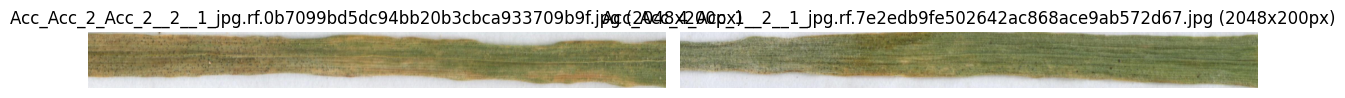

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(tiffs), figsize=(12, 4 * len(tiffs)))
if len(tiffs) == 1:
    axes = [axes]
for ax, (fid, name) in zip(axes, tiffs):
    img = cv2.imread(os.path.join("images", name))
    h, w = img.shape[:2]
    scale = 1400 / max(h, w)
    disp = cv2.resize(img, (int(w * scale), int(h * scale)))
    ax.imshow(cv2.cvtColor(disp, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name} ({w}x{h}px)")
    ax.axis("off")
plt.tight_layout(); plt.savefig("input_preview.png", dpi=100); plt.show()

## 7. Run the authors' script (SeptoSympto inference)

Execute `septo_sympto.py` **unchanged** as a subprocess with only the folder/extension/device overridden: `images/` input, `.jpg` extension (the published sample images are JPGs), CPU device, and all scientific parameters left at the authors' defaults (304×3072 crops, 472 px/cm, necrosis threshold 0.8, pycnidia threshold 0.3). The script crops each leaf (contours ≥ 50000 px in HSV [0,35,65]–[255,255,255]), runs the U-Net necrosis mask, YOLOv5 pycnidia detection, and writes `outputs/output_1/results.csv` plus annotated images.

*Documented discrepancy:* the README/paper describe a perimeter-to-area ratio cut-off of 0.8, but the pinned script uses 0.9 (`septo_sympto.py` line 272); we follow the pinned code.

**著者スクリプトの実行（日本語）:** `septo_sympto.py` を無変更のままサブプロセスで実行します（画像フォルダ・拡張子・デバイスのみ指定）。閾値等は著者既定値をそのまま使用します。

In [ ]:
import subprocess, sys, os, torch

# Pre-trust ultralytics/yolov5 for torch.hub so the authors' unchanged
# torch.hub.load('ultralytics/yolov5', 'custom', ...) call is non-interactive.
hub_dir = torch.hub.get_dir()
os.makedirs(hub_dir, exist_ok=True)
trusted = os.path.join(hub_dir, "trusted_list")
if "ultralytics_yolov5" not in (open(trusted).read() if os.path.exists(trusted) else ""):
    with open(trusted, "a") as f:
        f.write("ultralytics_yolov5\n")
print("torch hub trusted_list updated")

r = subprocess.run(
    [sys.executable, "septo_sympto.py", "-w", "images", "-e", ".jpg",
     "-d", "cpu", "-o", "results.csv"],
    capture_output=True, text=True, timeout=3600)
print(r.stdout[-3000:])
print(r.stderr[-3000:])
print("exit code:", r.returncode)
assert r.returncode == 0, 'septo_sympto.py failed - see output above'

torch hub trusted_list updated


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLOv5 🚀 2026-10-4 Python-3.13.15 torch-2.11.0+cpu CPU

Fusing layers... 
Model summary: 174 layers, 139,970,872 parameters, 0 gradients, 207.9 GFLOPs
Adding AutoShape... 

Septo-Sympto
Authors: Laura MATHIEU, Maxime REDER

CROP LEAF ON IMAGES 


INFER IMAGES INTO MODELS 


1/1 [==============================] - 33s 33s/step

1/1 [==============================] - 30s 30s/step

Create final result csv
Save results to outputs folder.
Save results at /content/outputs/output_0
Done!

2026-10-04 23:11:18.425837: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit

## 8. Results — measurements and annotated images

Show the measurement table (`results.csv`: leaf area in px/cm², necrosis number/area/ratio, pycnidia number/area) and the script's annotated output image (green necrosis contours, magenta pycnidia circles), rendered from the actual run above.

**結果（日本語）:** `results.csv` の測定表と、スクリプトが生成した注釈付き画像（緑: 壊死領域輪郭、マゼンタ: pycnidia 円）を表示します。

,leaf,leaf_area_px,leaf_area_cm2,necrosis_number,necrosis_area_ratio,necrosis_area_cm2,pycnidia_number,pycnidia_area_px,pycnidia_area_cm2,pycnidia_number_per_leaf_cm2,pycnidia_number_per_necrosis_cm2,pycnidia_area_cm2_per_necrosis_area_cm2,pycnidia_mean_area_cm2
0,Acc_Acc_4_Acc_1__2__1_jpg__1,304777.631579,1.3680,1,0.950,1.2991,487,14838.0042,0.0666,0.949635,374.874913,0.051266,0.000137
1,Acc_Acc_2_Acc_2__2__1_jpg__1,290000.000000,1.3017,1,0.978,1.2726,806,22676.3414,0.1018,0.977645,633.349049,0.079994,0.000126


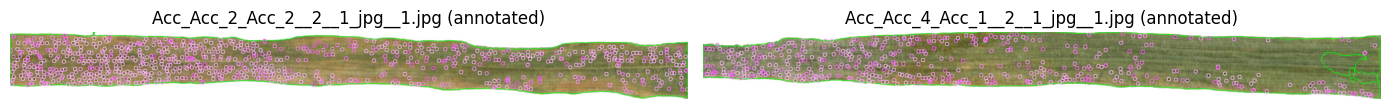

saved: results_export.csv


In [ ]:
import pandas as pd, glob, cv2

out_dirs = sorted(glob.glob("outputs/output_*"))
res = pd.read_csv(os.path.join(out_dirs[-1], "results.csv"))
display(res)

ann = sorted(glob.glob(os.path.join(out_dirs[-1], "images_output", "*.jpg")))
fig, axes = plt.subplots(1, len(ann), figsize=(14, 5))
if len(ann) == 1:
    axes = [axes]
for ax, p in zip(axes, ann):
    im = cv2.imread(p)
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(p) + " (annotated)")
    ax.axis("off")
plt.tight_layout(); plt.savefig("annotated_results.png", dpi=100); plt.show()
res.to_csv("results_export.csv", index=False)
print("saved: results_export.csv")

## 9. Interpretation and limitations

**What was verified:** the authors' pinned script, on a Colab CPU runtime, with the authors' checkpoint files and public sample scans, produced a per-leaf measurement table and annotated images — the paper's "Image analysis" pipeline (script_inference phase).

**What this does NOT verify:** the paper's reported correlations with experts (74–95%), the ImageJ comparison, transferability across datasets, or anything about training. Those require the full datasets and expert scores, which the authors state are available on request. A two-scan run is a functional demonstration, not a benchmark.

**Known limitations:** pycnidia metrics were reported weak even in the paper (P2 F1 = 0.34), so pycnidia counts on the sample may include false positives; results depend on scan orientation (leaves must be horizontal) and the 472 px/cm calibration for 1200-dpi scans.

**検証範囲（日本語）:** 本ノートブックは著者のスクリプトとモデルを用いた単一例の推論パイプラインの動作検証です。専門家との相関やデータセット横断の評価、学習の再現は含みません。pycnidia 検出は論文自体が弱い（F1 0.34）ため、サンプルでも誤検出を含み得ます。

**References**
- Mathieu, L., Reder, M., et al. *SeptoSympto...* preprint rs-3111942/v1; *Plant Methods* (2024).
- Code: https://github.com/maximereder/septo-sympto @ `cdeee81f6e424c39b00942d53873410e3945291a`
- U-Net training repo: https://github.com/maximereder/unet ; YOLOv5: https://github.com/ultralytics/yolov5